In [12]:
import micropip
await micropip.install('seaborn')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


In [13]:
import pyodide
from pyodide.http import pyfetch

response = await pyfetch("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv")
data = await response.bytes()

with open("WA_Fn-UseC_-Telco-Customer-Churn.csv", "wb") as f:
    f.write(data)

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print('Dataset loaded successfully!')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')

Dataset loaded successfully!
Shape: 7,043 rows x 21 columns


In [14]:
# Fix TotalCharges - convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill blanks with 0
df['TotalCharges'].fillna(0, inplace=True)

# Drop customerID
df.drop(columns=['customerID'], inplace=True)

# Convert SeniorCitizen from 0/1 to Yes/No
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# Check duplicates
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')

print(f'Cleaned dataset shape: {df.shape}')
print('Data cleaning complete! ✅')

Duplicate rows: 22
Cleaned dataset shape: (7043, 20)
Data cleaning complete! ✅


Not Churned: 5,174 (73.5%)
Churned:     1,869 (26.5%)


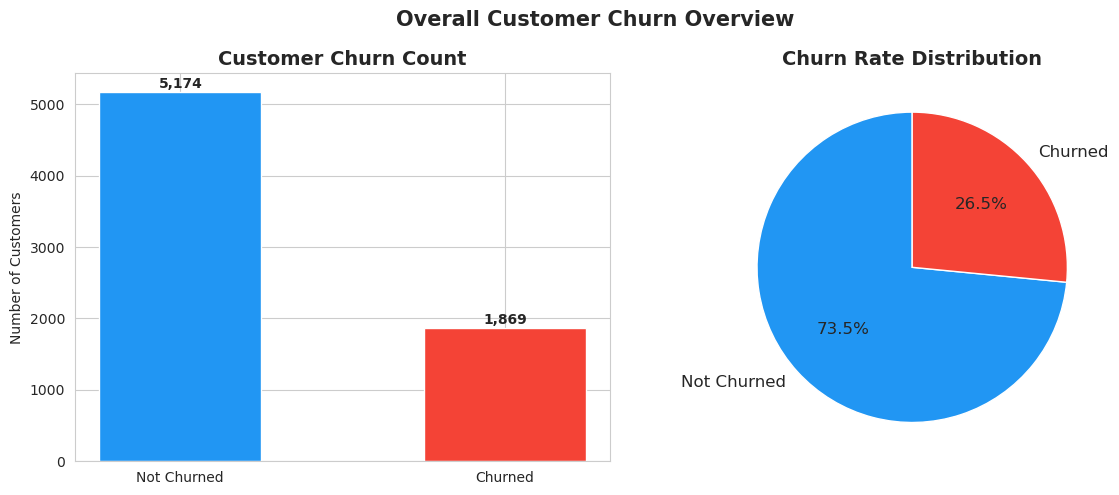

Chart complete! ✅


In [15]:
# Churn distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print(f'Not Churned: {churn_counts["No"]:,} ({churn_pct["No"]:.1f}%)')
print(f'Churned:     {churn_counts["Yes"]:,} ({churn_pct["Yes"]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['Not Churned', 'Churned'], churn_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
axes[0].set_title('Customer Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
            colors=['#2196F3', '#F44336'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn Rate Distribution', fontsize=14, fontweight='bold')

plt.suptitle('Overall Customer Churn Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('Chart complete! ✅')

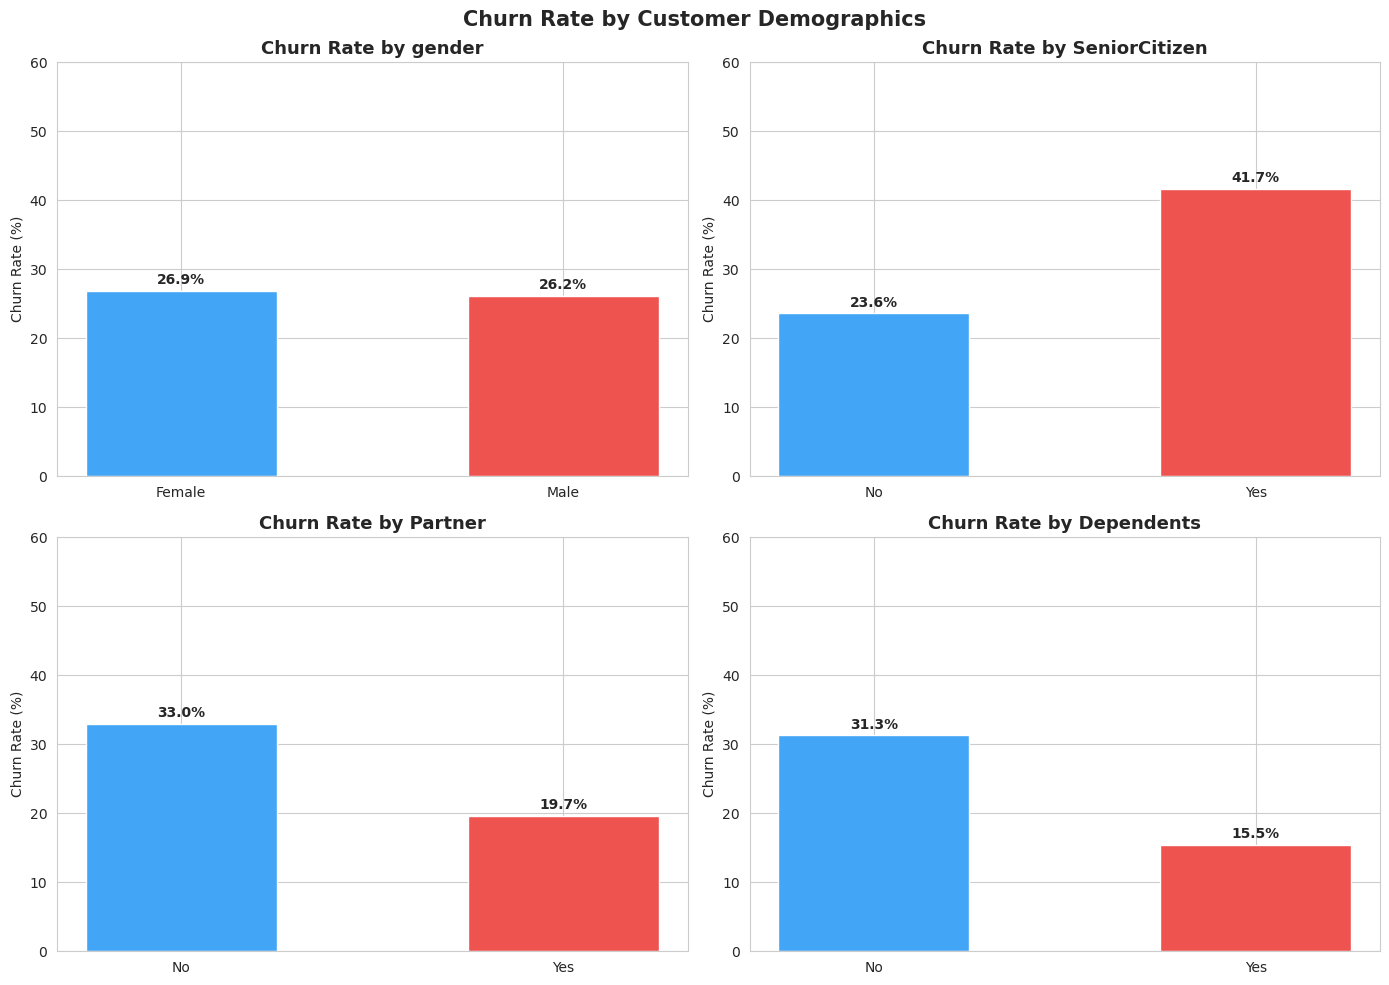

Chart complete! ✅


In [16]:
# Churn rate by demographics
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(demo_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [col, 'Churn Rate (%)']

    bars = axes[i].bar(churn_rate[col], churn_rate['Churn Rate (%)'],
                       color=['#42A5F5', '#EF5350', '#66BB6A', '#FFA726'][:len(churn_rate)],
                       edgecolor='white', width=0.5)
    axes[i].set_title(f'Churn Rate by {col}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_ylim(0, 60)
    for bar, val in zip(bars, churn_rate['Churn Rate (%)']):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 1, f'{val:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Churn Rate by Customer Demographics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('Chart complete! ✅')

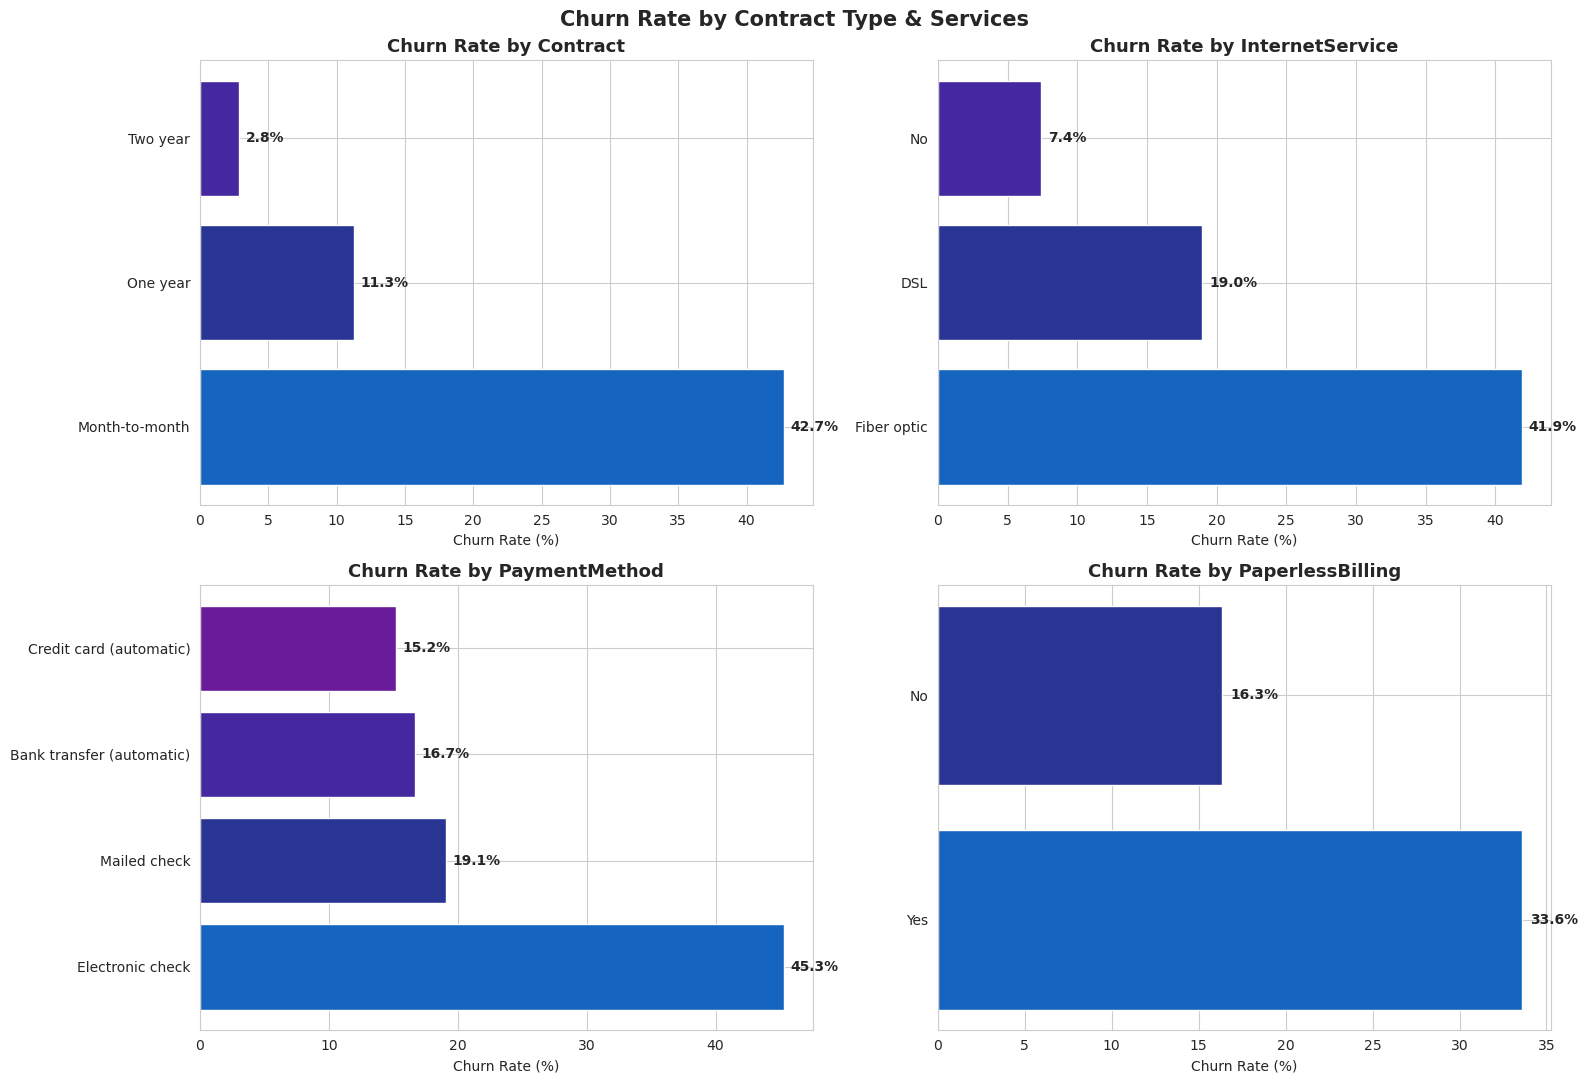

Chart complete! ✅


In [17]:
# Churn rate by contract & services
service_cols = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()
colors = ['#1565C0', '#283593', '#4527A0', '#6A1B9A', '#880E4F']

for i, col in enumerate(service_cols):
    churn_rate = df.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    churn_rate.columns = [col, 'Churn Rate (%)']
    churn_rate = churn_rate.sort_values('Churn Rate (%)', ascending=False)

    bars = axes[i].barh(churn_rate[col], churn_rate['Churn Rate (%)'],
                        color=colors[:len(churn_rate)], edgecolor='white')
    axes[i].set_title(f'Churn Rate by {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Churn Rate (%)')
    for bar, val in zip(bars, churn_rate['Churn Rate (%)']):
        axes[i].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontweight='bold')

plt.suptitle('Churn Rate by Contract Type & Services', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('Chart complete! ✅')

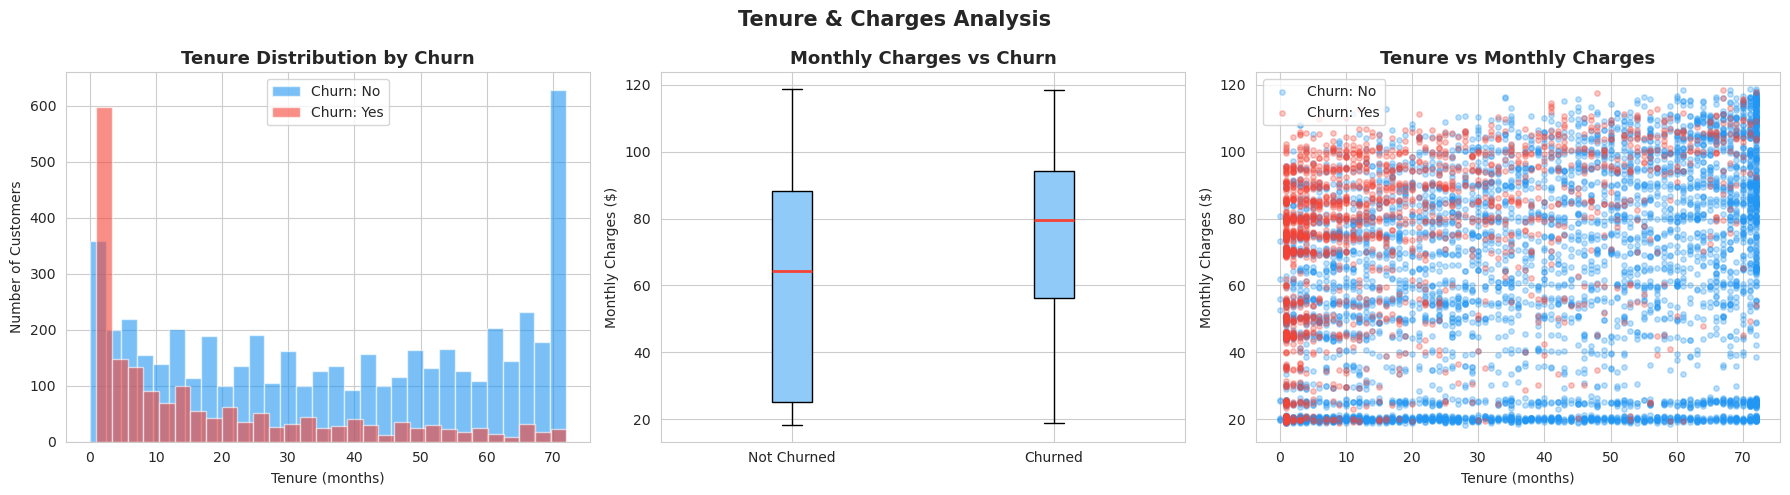

Chart complete! ✅


In [18]:
# Tenure & Charges Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Tenure histogram
for label, color in [('No', '#2196F3'), ('Yes', '#F44336')]:
    axes[0].hist(df[df['Churn'] == label]['tenure'], bins=30,
                 alpha=0.6, color=color, label=f'Churn: {label}')
axes[0].set_title('Tenure Distribution by Churn', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# Monthly charges box plot
churned = df[df['Churn'] == 'Yes']['MonthlyCharges']
not_churned = df[df['Churn'] == 'No']['MonthlyCharges']
axes[1].boxplot([not_churned, churned], labels=['Not Churned', 'Churned'],
                patch_artist=True,
                boxprops=dict(facecolor='#90CAF9'),
                medianprops=dict(color='#F44336', linewidth=2))
axes[1].set_title('Monthly Charges vs Churn', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Monthly Charges ($)')

# Scatter plot
for label, color in [('No', '#2196F3'), ('Yes', '#F44336')]:
    subset = df[df['Churn'] == label]
    axes[2].scatter(subset['tenure'], subset['MonthlyCharges'],
                    alpha=0.3, color=color, label=f'Churn: {label}', s=15)
axes[2].set_title('Tenure vs Monthly Charges', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Tenure (months)')
axes[2].set_ylabel('Monthly Charges ($)')
axes[2].legend()

plt.suptitle('Tenure & Charges Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print('Chart complete! ✅')

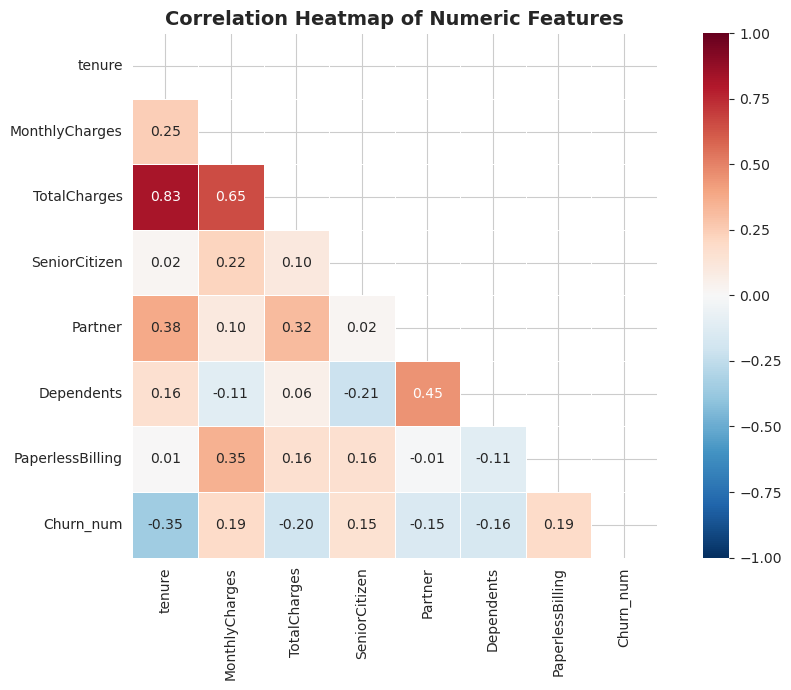

Chart complete! ✅


In [19]:
# Correlation heatmap
df_encoded = df.copy()
df_encoded['Churn_num'] = (df_encoded['Churn'] == 'Yes').astype(int)

binary_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
               'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_encoded[col] = (df_encoded[col].isin(['Yes', 'Female', '1'])).astype(int)

numeric_df = df_encoded[['tenure', 'MonthlyCharges', 'TotalCharges',
                          'SeniorCitizen', 'Partner', 'Dependents',
                          'PaperlessBilling', 'Churn_num']]

corr = numeric_df.corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Chart complete! ✅')

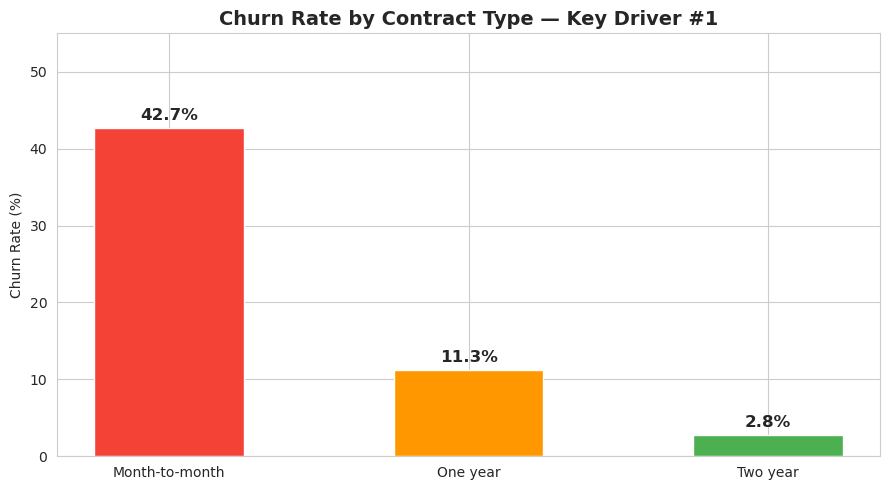

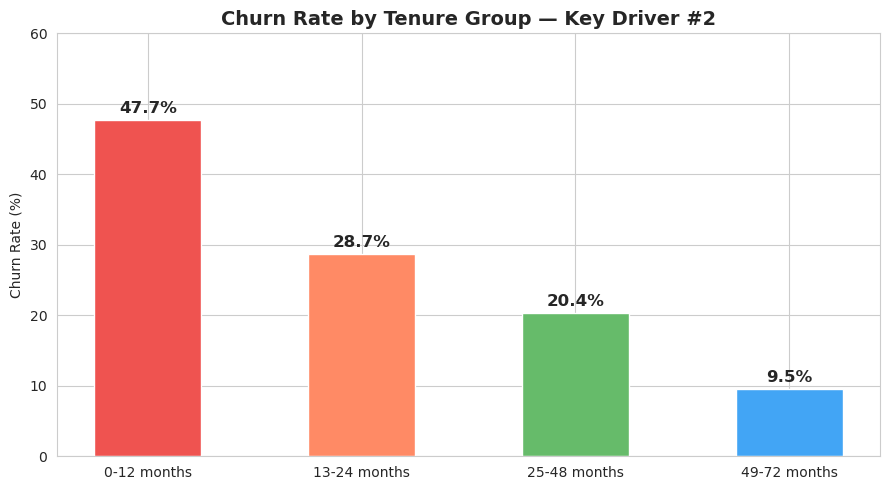

Charts complete! ✅


In [20]:
# Key Driver - Contract Type
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate (%)']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(contract_churn['Contract'], contract_churn['Churn Rate (%)'],
              color=['#F44336', '#FF9800', '#4CAF50'], edgecolor='white', width=0.5)
ax.set_title('Churn Rate by Contract Type — Key Driver #1',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 55)
for bar, val in zip(bars, contract_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1, f'{val:.1f}%', ha='center',
            fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Key Driver - Tenure Groups
df['TenureGroup'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                            labels=['0-12 months', '13-24 months',
                                    '25-48 months', '49-72 months'])
tenure_churn = df.groupby('TenureGroup')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
tenure_churn.columns = ['TenureGroup', 'Churn Rate (%)']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(tenure_churn['TenureGroup'].astype(str),
              tenure_churn['Churn Rate (%)'],
              color=['#EF5350', '#FF8A65', '#66BB6A', '#42A5F5'],
              edgecolor='white', width=0.5)
ax.set_title('Churn Rate by Tenure Group — Key Driver #2',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 60)
for bar, val in zip(bars, tenure_churn['Churn Rate (%)']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1, f'{val:.1f}%', ha='center',
            fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('Charts complete! ✅')

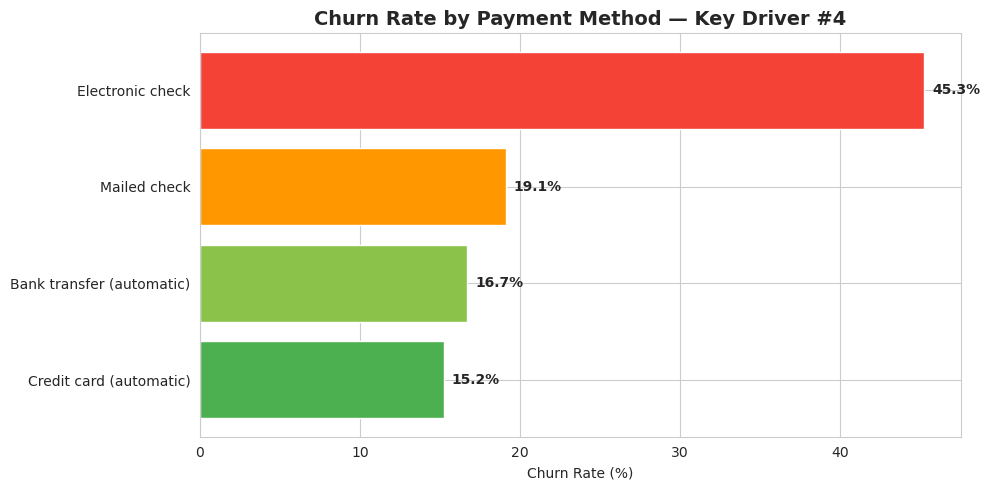

     BUSINESS INSIGHTS SUMMARY
Overall churn rate:           26.5%
Total customers churned:      1,869 of 7,043
Month-to-month churn rate:    42.7%
Fiber optic churn rate:       41.9%
Senior citizen churn rate:    41.7%
Avg monthly charges (churned): $74.44
Avg monthly charges (stayed):  $61.27
Avg tenure (churned):          18.0 months
Avg tenure (stayed):           37.6 months
Analysis Complete! ✅


In [21]:
# Key Driver - Payment Method
pay_churn = df.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100
).reset_index()
pay_churn.columns = ['PaymentMethod', 'Churn Rate (%)']
pay_churn = pay_churn.sort_values('Churn Rate (%)', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(pay_churn['PaymentMethod'], pay_churn['Churn Rate (%)'],
               color=['#4CAF50', '#8BC34A', '#FF9800', '#F44336'],
               edgecolor='white')
ax.set_title('Churn Rate by Payment Method — Key Driver #4',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Churn Rate (%)')
for bar, val in zip(bars, pay_churn['Churn Rate (%)']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Business Insights Summary
total = len(df)
churned = (df['Churn'] == 'Yes').sum()
churn_rate = churned / total * 100
mtm_churn = df[df['Contract'] == 'Month-to-month']['Churn'].value_counts(normalize=True)['Yes'] * 100
fiber_churn = df[df['InternetService'] == 'Fiber optic']['Churn'].value_counts(normalize=True)['Yes'] * 100
senior_churn = df[df['SeniorCitizen'] == 'Yes']['Churn'].value_counts(normalize=True)['Yes'] * 100
avg_monthly_churned = df[df['Churn'] == 'Yes']['MonthlyCharges'].mean()
avg_monthly_not = df[df['Churn'] == 'No']['MonthlyCharges'].mean()
avg_tenure_churned = df[df['Churn'] == 'Yes']['tenure'].mean()
avg_tenure_not = df[df['Churn'] == 'No']['tenure'].mean()

print('=' * 50)
print('     BUSINESS INSIGHTS SUMMARY')
print('=' * 50)
print(f'Overall churn rate:           {churn_rate:.1f}%')
print(f'Total customers churned:      {churned:,} of {total:,}')
print(f'Month-to-month churn rate:    {mtm_churn:.1f}%')
print(f'Fiber optic churn rate:       {fiber_churn:.1f}%')
print(f'Senior citizen churn rate:    {senior_churn:.1f}%')
print(f'Avg monthly charges (churned): ${avg_monthly_churned:.2f}')
print(f'Avg monthly charges (stayed):  ${avg_monthly_not:.2f}')
print(f'Avg tenure (churned):          {avg_tenure_churned:.1f} months')
print(f'Avg tenure (stayed):           {avg_tenure_not:.1f} months')
print('=' * 50)
print('Analysis Complete! ✅')